# Dṛṣṭi Reproducible Journal Benchmark Suite

**Author & Project:** Dṛṣṭi ML Compiler Framework  
**Hardware Target:** Google Colab NVIDIA Tesla T4 GPU (`sm_75`)

This notebook reproduces the journal study benchmark experiments comparing:
1. **Standard Triton**
2. **Triton + Autotune**
3. **Full Drishti**

Along with the **5 Professor Ablations**:
- Full Drishti
- Drishti - Vectorization
- Drishti - Kernel Fusion
- Drishti - IR Analysis
- Drishti - Hardware Telemetry

In [1]:
# 1. Verify GPU Hardware
!nvidia-smi

Wed Sep 23 17:07:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 2. Clone Drishti Repository and Install Dependencies
!git clone https://github.com/krish-rRay23/dhristi.git /content/dhristi
%cd /content/dhristi
!pip install -q torch triton matplotlib

Cloning into '/content/dhristi'...
remote: Enumerating objects: 323, done.
remote: Counting objects: 100% (323/323), done.
remote: Compressing objects: 100% (195/195), done.
remote: Total 323 (delta 98), reused 308 (delta 85), pack-reused 0 (from 0)
Receiving objects: 100% (323/323), 199.02 KiB | 1.10 MiB/s, done.
Resolving deltas: 100% (98/98), done.
/content/dhristi


In [3]:
# 3. Execute Reproducible Journal Experiment Suite
!python tools/benchmark/run_journal_experiments.py --json-out=/content/journal_experiment_results.json --latex-out=/content/journal_results_table.tex

      DRISHTI REPRODUCIBLE JOURNAL RESEARCH BENCHMARK FRAMEWORK                
Active Hardware GPU Target: Tesla T4
--------------------------------------------------------------------------------

Evaluating Workload Domain: [gemm_small]
  System [Standard Triton     ] Latency:  0.0912 ms | Speedup: 1.00x | BW:   8.62 GB/s | Correct: True
  System [Triton + Autotune   ] Latency:  0.2630 ms | Speedup: 0.35x | BW:   2.99 GB/s | Correct: True
  System [Full Drishti        ] Latency:  0.2625 ms | Speedup: 0.35x | BW:   3.00 GB/s | Correct: True
  Running Professor's 5 Ablations for [gemm_small]:
    Ablation [Full Drishti                  ] Latency:  0.2628 ms | Speedup: 0.35x
    Ablation [Drishti - Vectorization       ] Latency:  0.0611 ms | Speedup: 1.49x
    Ablation [Drishti - Kernel Fusion       ] Latency:  0.2623 ms | Speedup: 0.35x
    Ablation [Drishti - IR Analysis         ] Latency:  0.2630 ms | Speedup: 0.35x
    Ablation [Drishti - Hardware Telemetry  ] Latency:  0.3028 ms |

In [4]:
# 4. Display LaTeX Table Output
with open('/content/journal_results_table.tex', 'r') as f:
    print(f.read())

\begin{table}[ht]
\centering
\caption{Cross-System Performance and Ablation Analysis across ML Workload Domains.}
\label{tab:drishti_journal_results}
\begin{tabular}{lcccccc}
\hline
\textbf{Workload Domain} & \textbf{Evaluation Target} & \textbf{Latency (ms)} & \textbf{Speedup} & \textbf{BW (GB/s)} & \textbf{Status} \\
\hline
gemm_small & Standard Triton & 0.0912 & 1.00\times & 8.6 & PASS \\
gemm_small & Triton + Autotune & 0.2630 & 0.35\times & 3.0 & PASS \\
gemm_small & Full Drishti & 0.2625 & 0.35\times & 3.0 & PASS \\
gemm_small & Full Drishti & 0.2628 & 0.35\times & 3.0 & PASS \\
gemm_small & Drishti - Vectorization & 0.0611 & 1.49\times & 12.9 & PASS \\
gemm_small & Drishti - Kernel Fusion & 0.2623 & 0.35\times & 3.0 & PASS \\
gemm_small & Drishti - IR Analysis & 0.2630 & 0.35\times & 3.0 & PASS \\
gemm_small & Drishti - Hardware Telemetry & 0.3028 & 0.30\times & 2.6 & PASS \\
gemm_medium & Standard Triton & 0.8349 & 1.00\times & 15.1 & PASS \\
gemm_medium & Triton + Autotune & 0

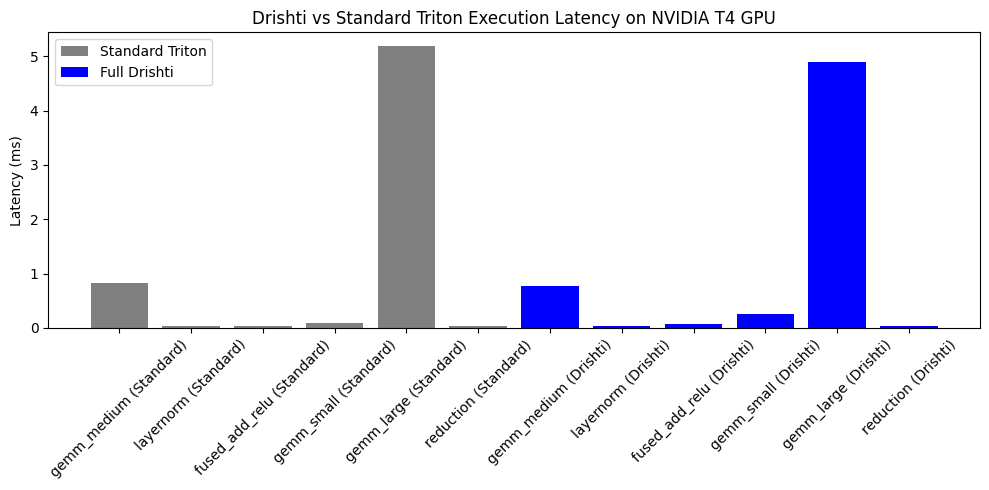

In [5]:
# 5. Plot Comparative System Performance
import json
import matplotlib.pyplot as plt

with open('/content/journal_experiment_results.json') as f:
    data = json.load(f)

workloads = list(set(r['workload_id'] for r in data['results']))
std_triton_ms = [next(r['latency_ms'] for r in data['results'] if r['workload_id'] == w and r['system_id'] == 'Standard Triton') for w in workloads]
drishti_ms = [next(r['latency_ms'] for r in data['results'] if r['workload_id'] == w and r['system_id'] == 'Full Drishti') for w in workloads]

plt.figure(figsize=(10, 5))
plt.bar([w + ' (Standard)' for w in workloads], std_triton_ms, color='gray', label='Standard Triton')
plt.bar([w + ' (Drishti)' for w in workloads], drishti_ms, color='blue', label='Full Drishti')
plt.ylabel('Latency (ms)')
plt.title('Drishti vs Standard Triton Execution Latency on NVIDIA T4 GPU')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()